## **Binary classification data-preprocessing**

In [2]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

from config import (
    CSV_PATH,
    XRAY_DIR,
    OUT_DIR,
)

def load_data(csv_path):
    df = pd.read_csv(csv_path)
    rename_map = {
        "Image Index": "IMGPATH",
        "Finding Labels": "DISEASELABEL",
        "Follow-up #": "FOLLOWUP",
        "Patient ID": "PATID",
        "Patient Age": "AGE",
        "Patient Gender": "GENDER",
        "View Position": "VP",
    }
    df = df.rename(columns=rename_map)
    return df

def find_full_path(image_name):
    for subdir in os.listdir(XRAY_DIR):
        full_path = os.path.join(XRAY_DIR, subdir, image_name)
        if os.path.exists(full_path):
            return full_path
    return None

def filter_selected_classes(df, selected_classes):
    include_only_pure = False
    df["DISEASELABEL"] = df["DISEASELABEL"].apply(lambda x: x.split("|") if isinstance(x, str) else [x])
    if include_only_pure:
        df = df[df["DISEASELABEL"].apply(lambda labels: len(labels) == 1 and labels[0] in selected_classes)].copy()
    else:
        df = df[df["DISEASELABEL"].apply(lambda labels: any(label in selected_classes for label in labels))].copy()
    return df

def check_multilabel_overlap(df, selected_classes):
    df = df[df["DISEASELABEL"].apply(lambda labels: sum(1 for label in labels if label in selected_classes) == 1)].copy()
    return df

def remove_random_percentage_by_class(df, keep_percentages):
    filtered_df = []
    for class_label, keep_percentage in keep_percentages.items():
        class_df = df[df["CLASS"] == class_label]
        random_keep = class_df.sample(frac=keep_percentage, random_state=42)
        filtered_df.append(random_keep)
    filtered_df = pd.concat(filtered_df)
    return filtered_df

def assign_class_labels(df, class_map):
    df["CLASS"] = df["DISEASELABEL"].apply(
        lambda labels: max((class_map.get(label, -1) for label in labels), default=-1)
    )
    df = df[
        [
            "IMGPATH",
            "DISEASELABEL",
            "CLASS",
            "FOLLOWUP",
            "PATID",
            "AGE",
            "GENDER",
            "VP",
        ]
    ]
    return df

def patient_aware_split(df, test_size=0.08, val_size=0.12):
    unique_patients = df["PATID"].unique()
    train_val_patients, test_patients = train_test_split(
        unique_patients, test_size=test_size, random_state=42
    )
    train_patients, val_patients = train_test_split(
        train_val_patients, test_size=val_size / (1 - test_size), random_state=42
    )
    train_df = df[df["PATID"].isin(train_patients)]
    val_df = df[df["PATID"].isin(val_patients)]
    test_df = df[df["PATID"].isin(test_patients)]
    return train_df, val_df, test_df

def preprocess_data(csv_path):
    selected_classes = {"No Finding", "Effusion"}
    class_map = {"No Finding": 0, "Effusion": 1}
    df = load_data(csv_path)
    df["IMGPATH"] = df["IMGPATH"].apply(find_full_path)
    df = filter_selected_classes(df, selected_classes)
    df = df[df["VP"] == "PA"]  # Uncomment to filter for PA view only
    df = assign_class_labels(df, class_map)
    df = remove_random_percentage_by_class(df, {0: 0.18, 1: 1})
    train_df, val_df, test_df = patient_aware_split(df)
    return train_df, val_df, test_df

train_df, val_df, test_df = preprocess_data(CSV_PATH)

train_df.to_csv(OUT_DIR / "binary_train.csv", index=False)
val_df.to_csv(OUT_DIR / "binary_val.csv", index=False)
test_df.to_csv(OUT_DIR / "binary_test.csv", index=False)


## **Patient overlap check**

In [10]:
# Check for patient ID overlaps
train_pids = set(train_df["PATID"])
val_pids = set(val_df["PATID"])
test_pids = set(test_df["PATID"])

overlap_train_val = train_pids & val_pids
overlap_train_test = train_pids & test_pids
overlap_val_test   = val_pids & test_pids

if overlap_train_val or overlap_train_test or overlap_val_test:
    print("[bold red]⚠️ Patient ID Overlap Detected Between Splits:[/bold red]")
    if overlap_train_val:
        print(f"[yellow]- Train ↔ Validation:[/] {len(overlap_train_val)} overlapping patient(s)")
    if overlap_train_test:
        print(f"[yellow]- Train ↔ Test:[/] {len(overlap_train_test)} overlapping patient(s)")
    if overlap_val_test:
        print(f"[yellow]- Validation ↔ Test:[/] {len(overlap_val_test)} overlapping patient(s)")
else:
    print("[bold green]✅ No patient ID overlap across splits.[/bold green]")

✅ No patient ID overlap across splits.

## **Data stats heatmap**

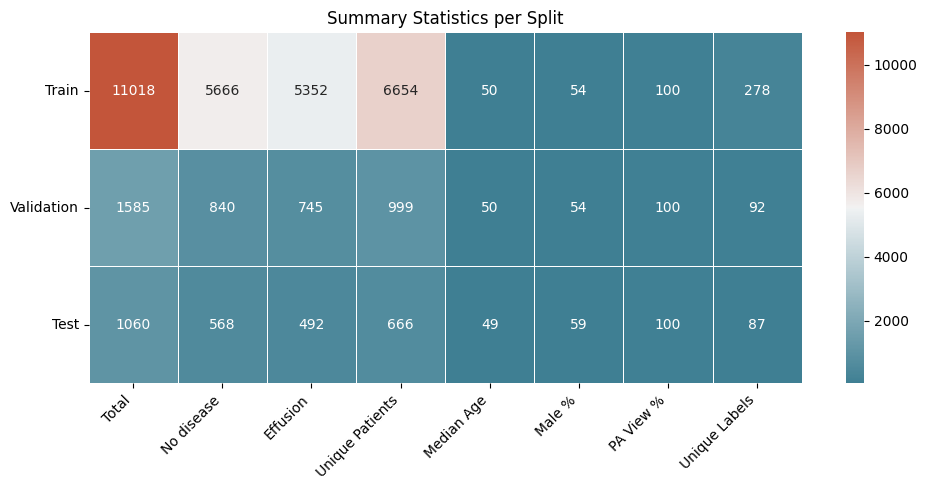

In [11]:
import seaborn as sns
from rich import print
import matplotlib.pyplot as plt

def quick_stats(df, name):
    return pd.Series({
        "Total": len(df),
        "No disease": (df["CLASS"] == 0).sum(),
        "Effusion": (df["CLASS"] == 1).sum(),
        "Unique Patients": df["PATID"].nunique(),
        "Median Age": df["AGE"].median(),
        "Male %": (df["GENDER"] == "M").mean() * 100,
        "PA View %": (df["VP"] == "PA").mean() * 100,
        "Unique Labels": df["DISEASELABEL"].apply(str).nunique()
    }, name=name)

summary_df = pd.concat([
    quick_stats(train_df, "Train"),
    quick_stats(val_df, "Validation"),
    quick_stats(test_df, "Test")
], axis=1).T

# print(summary_df.round(2))

heatmap_data = summary_df.astype(int)

plt.figure(figsize=(10, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",  # <- use integer format for annotation
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    linewidths=0.5,
    linecolor="white"
)

plt.title("Summary Statistics per Split")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



## **Compute mean & std values for x-ray images**

Computing mean and std: 100%|██████████| 345/345 [01:34<00:00,  3.63it/s]


0.07753004038489694 1.1558101171582273

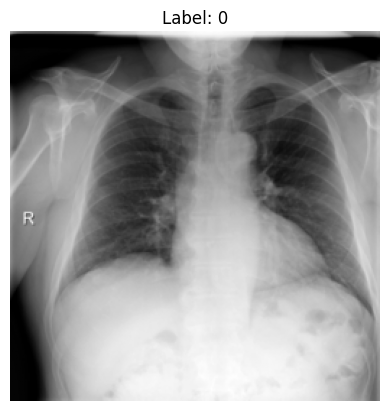

In [9]:
import torch
from tqdm import tqdm
from rich import print
from config import OUT_DIR
import matplotlib.pyplot as plt
from src.Dataset import ChestXRayDataset

train_dt = ChestXRayDataset(OUT_DIR / "binary_train.csv", transform=False)

def compute_mean_std(dataset):
    loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=False)
    psum = 0.0
    psum_sq = 0.0
    count = 0

    for imgs, _ in tqdm(loader, desc="Computing mean and std"):
        imgs = imgs.float().cpu()
        psum += imgs.sum().item()
        psum_sq += (imgs ** 2).sum().item()
        count += imgs.numel()

    mean = psum / count
    std = ((psum_sq / count) - (mean ** 2)) ** 0.5
    return mean, std

mean, std = compute_mean_std(train_dt)
print(mean, std)

# View one image from dataset
img, label = train_dt[0]
plt.imshow(img.squeeze(0), cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()